Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 37s 452ms/step - accuracy: 0.5846 - loss: 0.6179 - val_accuracy: 0.9000 - val_loss: 0.2512
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - accuracy: 0.9182 - loss: 0.2187 - val_accuracy: 0.8889 - val_loss: 0.2694
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 422ms/step - accuracy: 0.9305 - loss: 0.1806 - val_accuracy: 0.9185 - val_loss: 0.1843
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 496ms/step - accuracy: 0.9556 - loss: 0.1282 - val_accuracy: 0.9259 - val_loss: 0.1488
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 41s 490ms/step - accuracy: 0.9734 - loss: 0.0825 - val_accuracy: 0.9185 - val_loss: 0.1872
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 39s 512ms/step - accuracy: 0.9744 - loss: 0.0648 - val_accuracy: 0.9556 - val_loss: 0.1179
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 31s 404ms/step - accuracy: 0.9807 - loss: 0.0508 - val_accuracy: 0.9407 - val_loss: 0.1321
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 31s 407ms/step - accuracy: 0.9878 - loss: 0.0361 - val_accu

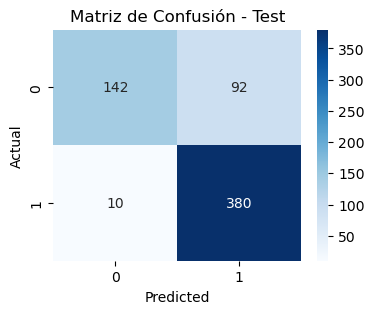

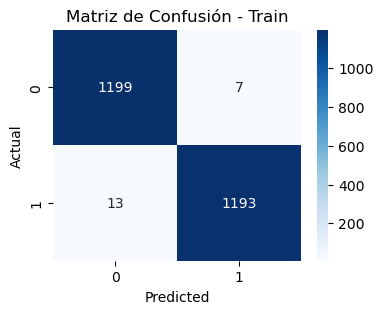

Reporte de Clasificación - Test:
              precision    recall  f1-score   support

      NORMAL       0.93      0.61      0.74       234
   PNEUMONIA       0.81      0.97      0.88       390

    accuracy                           0.84       624
   macro avg       0.87      0.79      0.81       624
weighted avg       0.85      0.84      0.83       624

Reporte de Clasificación - Train:
              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99      1206
   PNEUMONIA       0.99      0.99      0.99      1206

    accuracy                           0.99      2412
   macro avg       0.99      0.99      0.99      2412
weighted avg       0.99      0.99      0.99      2412



In [7]:
import os
import cv2
import numpy as np
import skimage
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from tensorflow.keras import models, layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

# Configuración
train_dir = "chest_xray/train/"
test_dir =  "chest_xray/test/"
val_dir =  "chest_xray/val/"

LOAD_FROM_IMAGES = False

def get_data(folder):
    X = []
    y = []
    for folderName in os.listdir(folder):
        if not folderName.startswith('.'):
            if folderName in ['NORMAL']:
                label = 0
            elif folderName in ['PNEUMONIA']:
                label = 1
            else:
                label = 2
            for image_filename in tqdm(os.listdir(folder + folderName)):
                img_file = cv2.imread(folder + folderName + '/' + image_filename)
                if img_file is not None:
                    img_file = skimage.transform.resize(img_file, (150, 150, 3),mode='constant',anti_aliasing=True)
                    img_file = rgb2gray(img_file)
                    img_arr = np.asarray(img_file)
                    X.append(img_arr)
                    y.append(label)
    X = np.asarray(X)
    y = np.asarray(y)
    return X,y


if LOAD_FROM_IMAGES:
    #cargamos las imágenes a los arrays
    X_train, y_train = get_data(train_dir)
    X_test, y_test= get_data(test_dir)
    X_val, y_val= get_data(val_dir)
    
    #grabamos los arrays en archivos
    np.save('xtrain.npy', X_train)
    np.save('ytrain.npy', y_train)
    np.save('xtest.npy', X_test)
    np.save('ytest.npy', y_test)
    np.save('xval.npy', X_val)
    np.save('yval.npy', y_val)
else:
    #cargamos los arrays anteriormente grabados
    X_train = np.load('xtrain.npy')
    y_train = np.load('ytrain.npy')
    X_test = np.load('xtest.npy')
    y_test = np.load('ytest.npy')
    X_val = np.load('xval.npy')
    y_val = np.load('yval.npy')

# Preprocesamiento
X_trainReshaped = X_train.reshape(len(X_train),150,150,1)
X_testReshaped = X_test.reshape(len(X_test),150,150,1)
X_valReshaped = X_val.reshape(len(X_val),150,150,1)

model = models.Sequential()

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(2, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento
history = model.fit(X_trainReshaped, 
                    y_train,
                    epochs=10,
                    validation_data=(X_valReshaped, y_val))

# Evaluación
loss, accuracy = model.evaluate(X_testReshaped, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
loss, accuracy = model.evaluate(X_trainReshaped, y_train)
print(f"Train Loss: {loss:.4f}")
print(f"Train Accuracy: {accuracy:.4f}")
loss, accuracy = model.evaluate(X_valReshaped, y_val)
print(f"Val Loss: {loss:.4f}")
print(f"Val Accuracy: {accuracy:.4f}")

# Predicciones
# test
pred_test = model.predict(X_testReshaped)
y_pred_test = np.argmax(pred_test, axis=1)

# train
pred_train = model.predict(X_trainReshaped)
y_pred_train = np.argmax(pred_train, axis=1)

# Matrices de Confusión
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_pred_test, "Matriz de Confusión - Test")
plot_confusion_matrix(y_train, y_pred_train, "Matriz de Confusión - Train")

# Reportes de Clasificación
print("Reporte de Clasificación - Test:")
print(classification_report(y_test, y_pred_test, target_names=["NORMAL", "PNEUMONIA"]))

print("Reporte de Clasificación - Train:")
print(classification_report(y_train, y_pred_train, target_names=["NORMAL", "PNEUMONIA"]))